# Covasim Graph Generation & Distance Comparison

Questo notebook:
1. Genera **3 tipologie x 3 grafi = 9 grafi** da simulazioni covasim con modelli di generazione diversi:
   - **A - Random**: layer unico, mixing omogeneo (`pop_type='random'`)
   - **B - Hybrid standard**: 4 layer (household/school/work/community), struttura per eta (`pop_type='hybrid'`, default)
   - **C - Hybrid household-heavy**: stessa struttura di B ma contatti household dominanti
2. Calcola embedding EDRep per ogni grafo
3. Misura tutte le distanze a coppie con **4 metriche**:
   - **EmbDistance** (distanza spettrale unmatched)
   - **w2_distance** (Wasserstein sulla matrice di Gram completa)
   - **w2_distance_classes (sex)** (Wasserstein per partizione sesso: femmina / maschio)
   - **w2_distance_classes (age)** (Wasserstein per partizione eta: 0-20 / 21-40 / 41-60 / 60+)
4. Visualizza le 4 matrici di distanza 9x9 come heatmap (griglia 2x2)
5. Valuta quale metrica separa meglio le tipologie tramite **Silhouette Score**, **Between/Within ratio** e **NMI** (con clustering NMF), tutti riportati in un'unica tabella comparativa


## 1. Setup

Importiamo le librerie necessarie e aggiungiamo la root del progetto al `sys.path` in modo da poter importare i moduli locali:
- **EDRep_main.EDRep** — embedding EDRep (passeggiate casuali + decomposizione spettrale)
- **functions.w2_distance_classes** — variante della distanza di Wasserstein su partizioni di nodi
- **covasim** — simulatore agent-based di reti di contatto epidemiologiche


In [14]:
# Uncomment to install covasim if not already available
# !pip install covasim

In [15]:
import sys
import os

# Aggiunge la root del progetto al path di Python per trovare i moduli locali
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

# Librerie scientifiche di base
import numpy as np
import networkx as nx          # manipolazione di grafi
import ot                      # optimal transport (distanza di Wasserstein)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd

# Simulatore di reti di contatto epidemiologiche
import covasim as cv

# Metriche di clustering e valutazione
from sklearn.metrics import silhouette_score, normalized_mutual_info_score
from sklearn.decomposition import NMF   # fattorizzazione non-negativa per il clustering
from sklearn.cluster import KMeans

# Moduli locali del progetto di tesi
from EDRep_main.EDRep import NodeEmbedding   # embedding spettrale dei nodi
from functions import w2_distance_classes     # Wasserstein per partizioni


## 2. Graph Generation

Usiamo **covasim** per generare reti di contatto realistiche. Ogni grafo rappresenta una popolazione di agenti con legami sociali estratti da layer distinti.

Tre tipologie strutturalmente diverse:

| Tipo | `pop_type` | Struttura | Caratteristica |
|------|------------|-----------|----------------|
| **A — Random** | `random` | layer unico `a` | mixing omogeneo, grado quasi-regolare |
| **B — Hybrid std** | `hybrid` | 4 layer h/s/w/c | struttura per eta, default covasim |
| **C — Hybrid hh** | `hybrid` | 4 layer h/s/w/c | household molto denso, cluster locali forti |

Per ciascuna tipologia generiamo **3 grafi** con seed diversi per valutare la variabilita intra-tipo.


In [16]:
def covasim_graph(pop_size=200, seed=0, pop_type='random', contacts=None):
    """
    Esegue una simulazione covasim e restituisce la rete di contatto come grafo NetworkX.

    Parametri
    ---------
    pop_size : numero di agenti nella popolazione
    seed     : seme per la riproducibilita della simulazione
    pop_type : 'random' (layer unico omogeneo) o 'hybrid' (4 layer, struttura per eta)
    contacts : dizionario {layer: n_contatti} oppure None per i default di covasim
    """
    # Parametri base della simulazione; contacts viene aggiunto solo se specificato
    kwargs = dict(pop_size=pop_size, rand_seed=seed, pop_type=pop_type, verbose=0)
    if contacts is not None:
        kwargs['contacts'] = contacts

    # Creiamo ed eseguiamo la simulazione (un solo step basta per estrarre la rete)
    sim = cv.Sim(**kwargs)
    sim.run()

    # In covasim 3.x si usa len(sim.people) al posto del deprecato sim.n
    n = len(sim.people)
    G = nx.Graph()
    G.add_nodes_from(range(n))

    # Ogni layer (household, school, work, community...) contiene array p1 e p2
    # con gli indici dei nodi ai due estremi di ciascun contatto
    for layer in sim.people.contacts.values():
        edges = zip(layer['p1'].tolist(), layer['p2'].tolist())
        G.add_edges_from(edges)

    # Associamo a ogni nodo gli attributi demografici estratti dalla simulazione
    for i in range(n):
        G.nodes[i]['sex'] = int(sim.people.sex[i])    # 0 = femmina, 1 = maschio
        G.nodes[i]['age'] = float(sim.people.age[i])  # eta in anni

    return G


In [17]:
POP_SIZE = 1000   # numero di nodi per grafo
SEEDS    = [0, 1, 2]  # tre seed per tipologia: misuriamo variabilita intra-tipo

# Definizione delle tre tipologie di grafo.
# Ogni dizionario specifica il label, il tipo di popolazione covasim e
# il numero di contatti per layer (None = default covasim).
GRAPH_TYPES = [
    {
        'label':    'A-Random',
        'pop_type': 'random',
        'contacts': {'a': 20},          # layer unico 'all', 20 contatti a testa
        'desc':     'Homogeneous random mixing, single contact layer',
    },
    {
        'label':    'B-Hybrid-std',
        'pop_type': 'hybrid',
        'contacts': None,               # default covasim: {h:2, s:20, w:16, c:20}
        'desc':     'Realistic 4-layer network (household/school/work/community)',
    },
    {
        'label':    'C-Hybrid-hh',
        'pop_type': 'hybrid',
        'contacts': {'h': 8, 's': 5, 'w': 5, 'c': 5},  # household dominante
        'desc':     'Household-heavy: dense local clusters, sparse other layers',
    },
]

# Liste accumulate: un elemento per ognuno dei 9 grafi (3 tipi x 3 seed)
graphs       = []  # grafi NetworkX
graph_labels = []  # etichetta breve, es. 'A-0', 'B-2'
type_labels  = []  # id intero del tipo: 0=A, 1=B, 2=C (ground truth per i cluster)

for t_idx, gtype in enumerate(GRAPH_TYPES):
    print(f"\n--- Type {gtype['label']}: {gtype['desc']} ---")
    for seed in SEEDS:
        G = covasim_graph(pop_size=POP_SIZE, seed=seed,
                          pop_type=gtype['pop_type'], contacts=gtype['contacts'])
        n_female = sum(1 for _, d in G.nodes(data=True) if d['sex'] == 0)
        n_male   = sum(1 for _, d in G.nodes(data=True) if d['sex'] == 1)
        print(f"  seed={seed}: {G.number_of_nodes()} nodes, "
              f"{G.number_of_edges()} edges | female={n_female}, male={n_male}")
        graphs.append(G)
        graph_labels.append(f"{gtype['label'][:1]}-{seed}")
        type_labels.append(t_idx)  # etichetta di tipo per le metriche di clustering

N = len(graphs)  # 9 grafi totali
print(f"\nTotal: {N} graphs, labels: {graph_labels}")



--- Type A-Random: Homogeneous random mixing, single contact layer ---


  seed=0: 1000 nodes, 9922 edges | female=517, male=483
  seed=1: 1000 nodes, 10029 edges | female=494, male=506
  seed=2: 1000 nodes, 9842 edges | female=534, male=466

--- Type B-Hybrid-std: Realistic 4-layer network (household/school/work/community) ---
  seed=0: 1000 nodes, 17137 edges | female=517, male=483
  seed=1: 1000 nodes, 17168 edges | female=494, male=506
  seed=2: 1000 nodes, 17247 edges | female=534, male=466

--- Type C-Hybrid-hh: Household-heavy: dense local clusters, sparse other layers ---
  seed=0: 1000 nodes, 8267 edges | female=517, male=483
  seed=1: 1000 nodes, 8342 edges | female=494, male=506
  seed=2: 1000 nodes, 8386 edges | female=534, male=466

Total: 9 graphs, labels: ['A-0', 'A-1', 'A-2', 'B-0', 'B-1', 'B-2', 'C-0', 'C-1', 'C-2']


## 3. Node Embeddings (EDRep)

**EDRep** associa a ogni nodo un vettore in $\mathbb{R}^d$ che codifica la sua struttura locale e globale nel grafo tramite decomposizione spettrale della matrice di diffusione.

`NodeEmbedding` prende la matrice di adiacenza sparsa e restituisce la matrice $X \in \mathbb{R}^{n \times d}$, dove $n$ e il numero di nodi e $d$ (`dim`) e la dimensione dello spazio di embedding.

Lo stesso `seed` numpy viene usato per tutti i grafi per garantire la riproducibilita dei passi stocastici interni.


In [18]:
def node_embedding(G, dim=16, seed=42):
    """
    Calcola l'embedding EDRep per il grafo G.

    Parametri
    ---------
    G   : grafo NetworkX
    dim : dimensione dello spazio di embedding (numero di componenti spettrali)
    seed: seme numpy per la riproducibilita

    Restituisce
    -----------
    X : matrice (n_nodi x dim) con i vettori di embedding di ogni nodo
    """
    # Convertiamo il grafo in matrice di adiacenza sparsa CSR:
    # NodeEmbedding lavora internamente con operazioni su matrici sparse
    A = nx.to_scipy_sparse_array(G, format='csr')

    np.random.seed(seed)  # fissa la randomicita prima di ogni embedding

    # k=1: un solo ordine di diffusione (passeggiate di lunghezza 1)
    emb = NodeEmbedding(A, dim=dim, k=1, verbose=False)
    return emb.X  # matrice (n_nodi x dim)


In [26]:
DIM = 32  # dimensione dello spazio di embedding per tutti i grafi

# Calcoliamo l'embedding per ciascuno dei 9 grafi.
# Ogni matrice X ha forma (200, 16): 200 nodi, ognuno con un vettore 16-dimensionale.
embeddings = []
for i, G in enumerate(graphs):
    X = node_embedding(G, dim=DIM)
    embeddings.append(X)
    print(f"{graph_labels[i]}: embedding shape {X.shape}")


A-0: embedding shape (1000, 32)
A-1: embedding shape (1000, 32)
A-2: embedding shape (1000, 32)
B-0: embedding shape (1000, 32)
B-1: embedding shape (1000, 32)
B-2: embedding shape (1000, 32)
C-0: embedding shape (1000, 32)
C-1: embedding shape (1000, 32)
C-2: embedding shape (1000, 32)


## 4. Distance Functions

Quattro metriche per confrontare coppie di grafi a partire dai loro embedding:

### EmbDistance (distanza spettrale unmatched)
Confronta gli spettri delle matrici di Gram $X^\top X$ dei due embedding. Calcola $\|\lambda_1 - \lambda_2\|_2$ dove $\lambda_i$ sono gli autovalori normalizzati per $n_i$. Non richiede lo stesso numero di nodi.

### w2_distance (Wasserstein sulla matrice di Gram)
Costruisce $S = X X^\top$, estrae il triangolo superiore come distribuzione 1D e calcola la distanza di Wasserstein-2 tra le due distribuzioni.

### w2_distance_classes (sex)
Calcola la distanza separatamente per femmine e maschi e combina i risultati come norma euclidea dei blocchi. Usa l'attributo `sex` di ogni nodo.

### w2_distance_classes (age)
Stessa logica della versione per sesso, ma con **4 fasce di eta**: 0-20, 21-40, 41-60, 60+. Cattura differenze strutturali legate alla distribuzione demografica per eta.

Le funzioni `sex_partition` e `age_partition` suddividono le righe dell'embedding in base agli attributi nodali, restituendo una lista di sottomatrici (una per classe).


In [27]:
def EmbDistance(X, Y, distance_type='unmatched'):
    """
    Distanza tra due grafi basata sui loro embedding.

    - unmatched: confronta gli spettri delle Gram normalizzate (non richiede n1==n2).
    - matched  : norma di Frobenius della differenza delle Gram (richiede n1==n2).
    """
    n1, d1 = X.shape
    n2, d2 = Y.shape

    if d1 != d2:
        raise ValueError('The embedding matrices have different dimensions')
    if distance_type not in ['unmatched', 'matched']:
        raise ValueError('distance_type must be unmatched or matched')
    if distance_type == 'matched' and n1 != n2:
        raise ValueError('Matched distance requires same number of nodes')

    if distance_type == 'matched':
        # ||X^T X - Y^T Y||_F calcolata tramite l'identita bilineare
        Mxx = X.T @ X
        Mxy = X.T @ Y
        Myy = Y.T @ Y
        return np.sqrt(np.abs(
            np.linalg.norm(Mxx)**2 + np.linalg.norm(Myy)**2 - 2*np.linalg.norm(Mxy)**2
        ))
    else:
        # Autovalori della Gram normalizzata per numero di nodi.
        # La norma L2 della differenza degli spettri misura la diversita strutturale.
        lam1 = np.linalg.eigvalsh(X.T @ X) / n1
        lam2 = np.linalg.eigvalsh(Y.T @ Y) / n2
        return np.linalg.norm(lam1 - lam2)


def w2_distance(emb_1, emb_2):
    """
    Distanza di Wasserstein-2 tra due grafi tramite le loro matrici di Gram.

    S = X X^T e la matrice di similarita tra tutti i nodi. Trattando i valori
    del triangolo superiore come distribuzione 1D, la Wasserstein misura quanto
    diversamente sono distribuite tali similarita nei due grafi.
    """
    # Matrice di Gram (n x n): S[i,j] = <x_i, x_j>
    S_1 = emb_1 @ emb_1.T
    S_2 = emb_2 @ emb_2.T

    # k=1 esclude la diagonale per non contare l'auto-similarita
    idx_1 = np.triu_indices_from(S_1, k=1)
    idx_2 = np.triu_indices_from(S_2, k=1)
    vals_S_1 = S_1[idx_1]
    vals_S_2 = S_2[idx_2]

    # Wasserstein-2 unidimensionale: radice del costo di trasporto ottimale
    wd2 = ot.wasserstein_1d(vals_S_1, vals_S_2, p=2)**(1/2)
    return wd2


def sex_partition(G, X):
    """
    Separa le righe dell'embedding X in base all'attributo sex del nodo.
    Restituisce [X_femmine, X_maschi].
    """
    sexes = np.array([G.nodes[i]['sex'] for i in range(G.number_of_nodes())])
    return [X[sexes == 0], X[sexes == 1]]


def age_partition(G, X):
    """
    Separa le righe dell'embedding X in 4 fasce di eta:
        0-20 | 21-40 | 41-60 | 60+

    Restituisce una lista di 4 sottomatrici (una per fascia).
    w2_distance_classes confrontera i blocchi corrispondenti tra due grafi.
    """
    ages = np.array([G.nodes[i]['age'] for i in range(G.number_of_nodes())])
    return [
        X[ages <= 20],                          # 0-20
        X[(ages > 20) & (ages <= 40)],          # 21-40
        X[(ages > 40) & (ages <= 60)],          # 41-60
        X[ages > 60],                           # 60+
    ]


## 5. Pairwise Distance Matrices

Calcoliamo **4 matrici di distanza 9x9**, una per ciascuna metrica. Ogni cella $(i,j)$ contiene la distanza tra il grafo $i$ e il grafo $j$.

Il loop percorre solo il triangolo superiore ($i < j$) e poi simmetrizza, evitando calcoli ridondanti. Per le due varianti di `w2_distance_classes` le partizioni dei nodi (per sesso e per eta) vengono costruite al volo a partire dagli attributi del grafo.


In [28]:
# Inizializziamo le quattro matrici di distanza N x N con zeri
D_emb = np.zeros((N, N))  # EmbDistance (confronto spettrale)
D_w2  = np.zeros((N, N))  # Wasserstein sulla Gram completa
D_cls = np.zeros((N, N))  # Wasserstein per partizione per sesso
D_age = np.zeros((N, N))  # Wasserstein per partizione per eta (4 fasce)

# Loop sul triangolo superiore: per i < j calcoliamo D[i,j],
# poi copiamo in D[j,i] per ottenere una matrice simmetrica
for i in range(N):
    for j in range(i + 1, N):
        D_emb[i, j] = EmbDistance(embeddings[i], embeddings[j])
        D_w2 [i, j] = w2_distance(embeddings[i], embeddings[j])

        # w2_distance_classes prende le partizioni (lista di sottomatrici)
        # di entrambi i grafi e restituisce una tupla; il [0] e la distanza scalare
        D_cls[i, j] = w2_distance_classes(
            sex_partition(graphs[i], embeddings[i]),
            sex_partition(graphs[j], embeddings[j])
        )[0]
        D_age[i, j] = w2_distance_classes(
            age_partition(graphs[i], embeddings[i]),
            age_partition(graphs[j], embeddings[j])
        )[0]

        # Simmetrizzazione: d(i,j) = d(j,i)
        D_emb[j, i] = D_emb[i, j]
        D_w2 [j, i] = D_w2 [i, j]
        D_cls[j, i] = D_cls[i, j]
        D_age[j, i] = D_age[i, j]

print('EmbDistance matrix:\n', np.round(D_emb, 5))
print('\nw2_distance matrix:\n', np.round(D_w2, 5))
print('\nw2_distance_classes (sex) matrix:\n', np.round(D_cls, 5))
print('\nw2_distance_classes (age) matrix:\n', np.round(D_age, 5))


EmbDistance matrix:
 [[0.      0.0055  0.00828 0.08343 0.0874  0.09362 0.06087 0.05677 0.05997]
 [0.0055  0.      0.00622 0.08433 0.08839 0.09447 0.05758 0.05322 0.05652]
 [0.00828 0.00622 0.      0.08076 0.08482 0.09075 0.05422 0.04989 0.05285]
 [0.08343 0.08433 0.08076 0.      0.00509 0.01142 0.08685 0.08815 0.08838]
 [0.0874  0.08839 0.08482 0.00509 0.      0.00761 0.09021 0.09167 0.09181]
 [0.09362 0.09447 0.09075 0.01142 0.00761 0.      0.09333 0.09503 0.0949 ]
 [0.06087 0.05758 0.05422 0.08685 0.09021 0.09333 0.      0.00989 0.01142]
 [0.05677 0.05322 0.04989 0.08815 0.09167 0.09503 0.00989 0.      0.00817]
 [0.05997 0.05652 0.05285 0.08838 0.09181 0.0949  0.01142 0.00817 0.     ]]

w2_distance matrix:
 [[0.      0.00135 0.00243 0.02795 0.0299  0.03145 0.03826 0.03855 0.03826]
 [0.00135 0.      0.00128 0.02698 0.02895 0.03033 0.03763 0.03798 0.03764]
 [0.00243 0.00128 0.      0.0259  0.02788 0.0292  0.03671 0.03711 0.03671]
 [0.02795 0.02698 0.0259  0.      0.00235 0.00799 0.0215

## 6. Visualization

Visualizziamo le **4 matrici di distanza come heatmap** disposte in una griglia 2x2. Una buona metrica mostrera valori bassi all'interno dei blocchi diagonali (grafi dello stesso tipo) e valori alti fuori dai blocchi (tipi diversi).

Le linee navy delimitano i tre blocchi A, B, C. La colormap va da giallo (distanza bassa) a rosso (distanza alta).


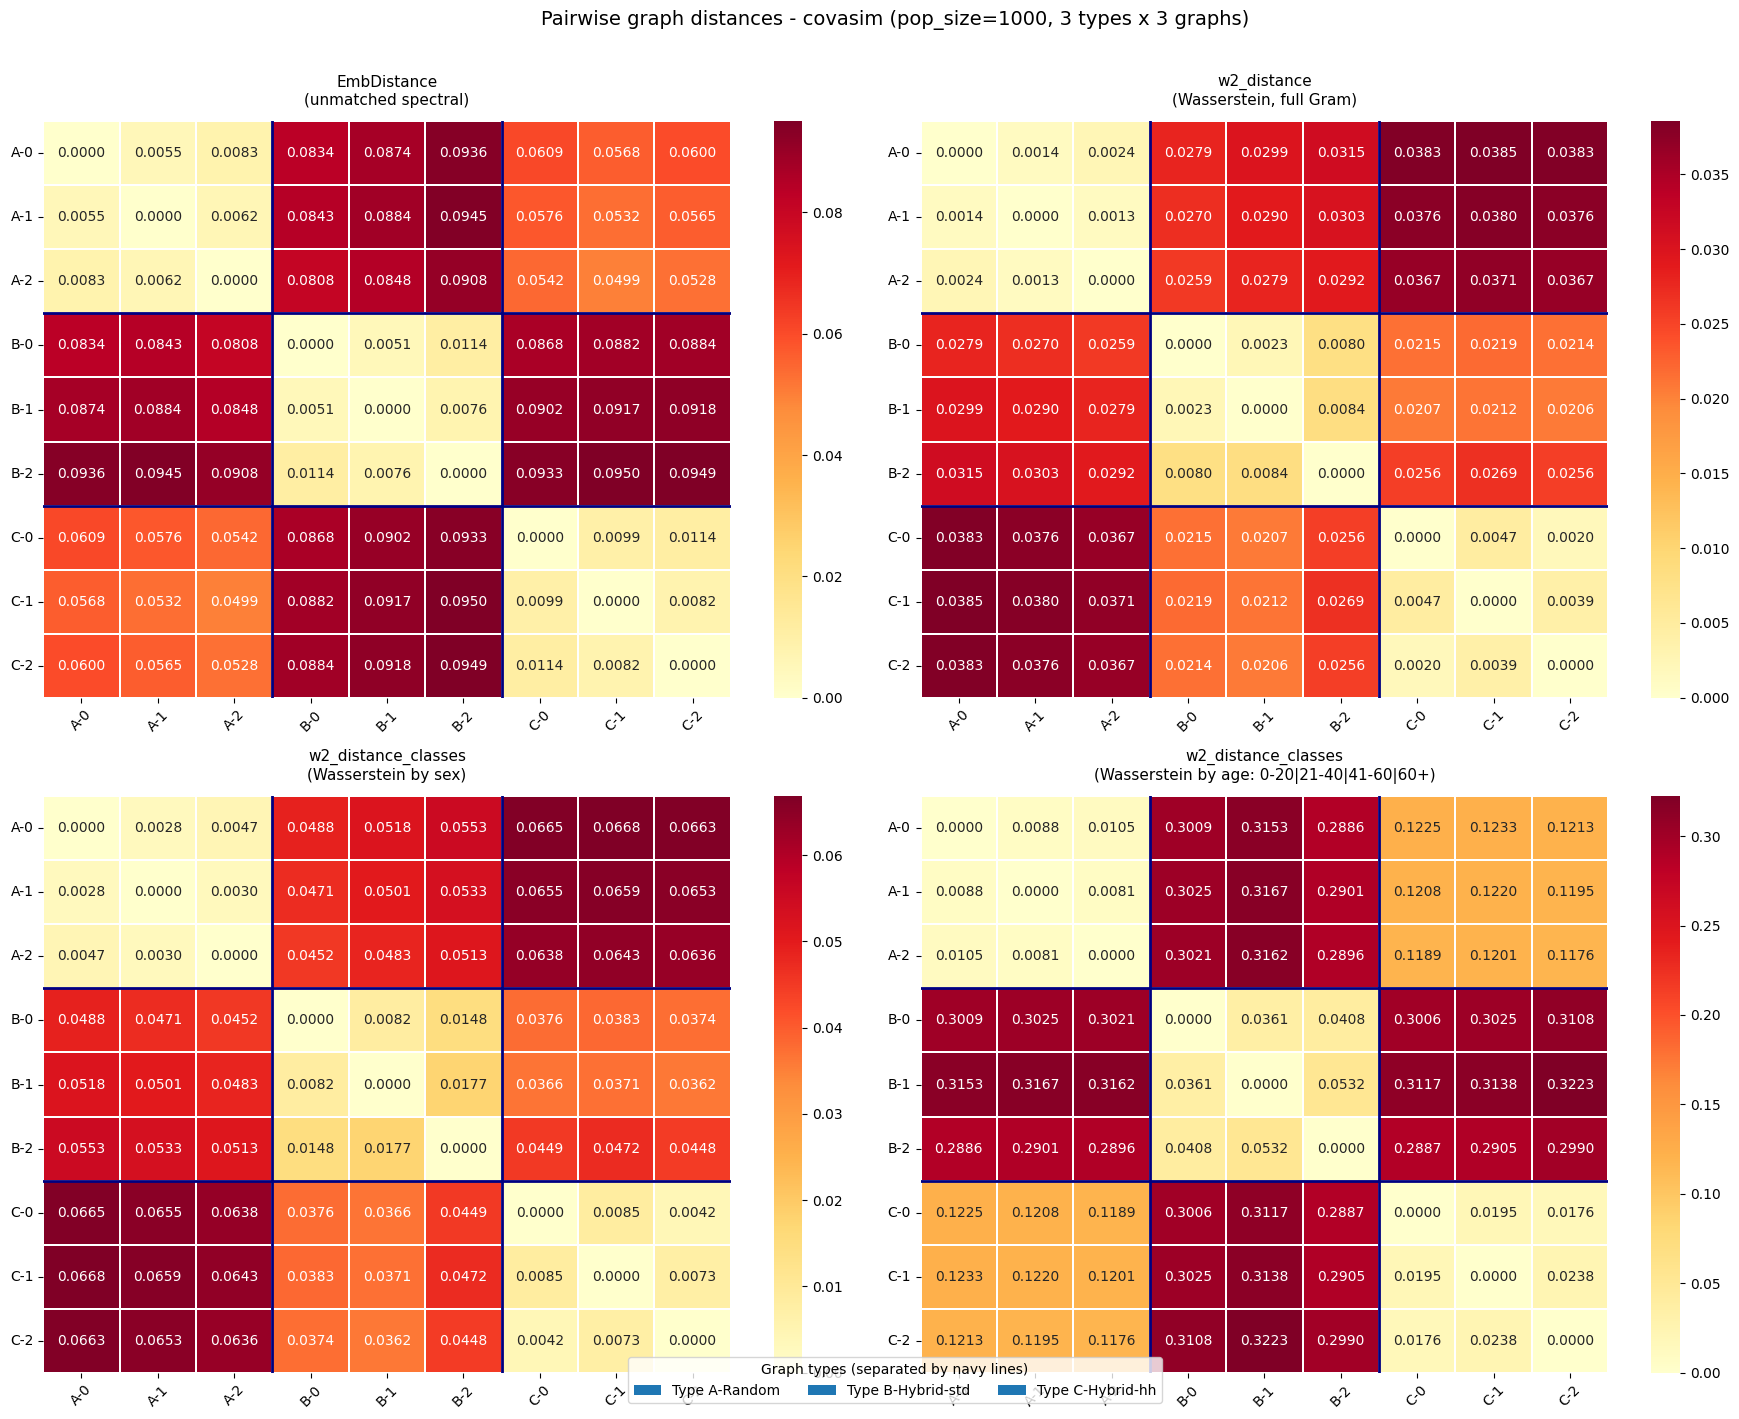

In [29]:
GROUP_SIZE = len(SEEDS)   # = 3 grafi per tipologia
type_names = [gt['label'] for gt in GRAPH_TYPES]

# Griglia 2x2: una heatmap per ciascuna delle quattro metriche
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()  # appiattita per iterare comodamente

matrices = [
    (D_emb, 'EmbDistance\n(unmatched spectral)'),
    (D_w2,  'w2_distance\n(Wasserstein, full Gram)'),
    (D_cls, 'w2_distance_classes\n(Wasserstein by sex)'),
    (D_age, 'w2_distance_classes\n(Wasserstein by age: 0-20|21-40|41-60|60+)'),
]

for ax, (mat, title) in zip(axes, matrices):
    sns.heatmap(
        mat,
        ax=ax,
        annot=True,
        fmt='.4f',
        cmap='YlOrRd',   # giallo = bassa distanza, rosso = alta distanza
        linewidths=0.3,
        xticklabels=graph_labels,
        yticklabels=graph_labels,
    )
    # Linee navy ogni GROUP_SIZE righe/colonne per delimitare i blocchi di tipologia
    for k in range(GROUP_SIZE, N, GROUP_SIZE):
        ax.axhline(k, color='navy', linewidth=2)
        ax.axvline(k, color='navy', linewidth=2)

    ax.set_title(title, pad=12, fontsize=11)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

# Legenda comune dei tipi di grafo
patches = [mpatches.Patch(label=f'Type {t}') for t in type_names]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=10,
           title='Graph types (separated by navy lines)', bbox_to_anchor=(0.5, 0.01))

plt.suptitle(
    f'Pairwise graph distances - covasim (pop_size={POP_SIZE}, 3 types x {GROUP_SIZE} graphs)',
    fontsize=14, y=1.01
)
plt.tight_layout()
plt.show()


In [30]:
def bw_ratio(D, labels):
    """
    Between/Within ratio: rapporto tra distanza media inter-gruppo e intra-gruppo.

    Valori > 1 indicano che i grafi dello stesso tipo sono mediamente piu vicini
    tra loro che ai grafi di tipo diverso. Valori piu alti = separazione migliore.
    """
    labels = np.array(labels)
    # Coppie con stessa etichetta -> distanze intra-gruppo (within)
    within  = [D[i, j] for i in range(len(labels))
                        for j in range(i + 1, len(labels)) if labels[i] == labels[j]]
    # Coppie con etichette diverse -> distanze inter-gruppo (between)
    between = [D[i, j] for i in range(len(labels))
                        for j in range(i + 1, len(labels)) if labels[i] != labels[j]]
    return np.mean(between) / np.mean(within)


## 7. Separation Metrics

Per valutare quale distanza separa meglio le 3 tipologie di grafo usiamo tre metriche complementari, calcolate per tutte e 4 le distanze nella sezione 8:

- **Silhouette Score** (`sklearn`, `metric='precomputed'`): per ogni grafo misura quanto e piu vicino ai grafi della sua tipologia rispetto alle altre. Range [-1, 1]; valori piu alti = separazione migliore.
- **Between/Within ratio**: rapporto tra distanza media *inter*-tipologia e distanza media *intra*-tipologia. Valori > 1 e piu alti = separazione migliore.
- **NMI** (Normalized Mutual Information): confronta le etichette predette da `ClusterNMF` con il ground truth. Range [0, 1]; NMI=1 = clustering perfetto.


## 8. NMF Clustering & Tabella Comparativa

Applichiamo **ClusterNMF** (NMF + k-means, 21 run) su ciascuna delle 4 matrici di distanza per ottenere un'assegnazione di cluster sui 9 grafi, confrontata con le etichette vere tramite **NMI**.

La tabella finale riporta **Silhouette Score**, **BW Ratio** e **NMI** per tutte e 4 le metriche in un unico confronto, cosi da identificare direttamente quale distanza performa meglio.

- `ClusterNMF(D, k=3)` — decompone `D` con NMF e clusterizza in k-means; restituisce le etichette predette.
- **NMI** e invariante alla permutazione delle etichette: il cluster '0' predetto puo corrispondere a qualsiasi tipo (A, B o C) e la metrica lo gestisce automaticamente.


In [ ]:
def NMF_kmeans(M, k):
    """
    Singola esecuzione di NMF + k-means sulla matrice M.

    Passaggi:
    1. Aggiunge alla diagonale la media degli elementi non-zero: rende M
       strettamente positiva e migliora la stabilita della NMF.
    2. Normalizza M per la sua media globale (scala i valori intorno a 1).
    3. Applica NMF con k componenti: M ~ W H, con H di forma (k, n).
       Le colonne di H^T (n x k) sono i descrittori latenti di ciascun punto.
    4. Applica k-means su H^T per assegnare ogni punto a un cluster.

    Restituisce le etichette predette e l'inerzia k-means (usata per la selezione).
    """
    n, _ = M.shape
    # Perturbazione diagonale: rende la matrice strettamente positiva
    Mt = M + np.eye(n) * np.mean(M[M.nonzero()])
    Mt = Mt / np.mean(Mt)  # normalizzazione per stabilita numerica

    # NMF: decompone Mt ~ W @ H; components_ e H di forma (k, n)
    Y = NMF(n_components=k, max_iter=2000).fit(Mt).components_

    # K-means su Y^T (n x k): ogni riga e il vettore latente di un punto
    kmeans = KMeans(n_clusters=k, n_init=10).fit(Y.T)
    return kmeans.labels_, np.abs(kmeans.score(Y.T))  # score = inerzia (negativa)


def ClusterNMF(M, k):
    """
    Clustering robusto tramite NMF + k-means con 21 ripetizioni indipendenti.

    NMF e k-means sono sensibili all'inizializzazione casuale: eseguiamo
    l'algoritmo 21 volte e teniamo il risultato con l'inerzia minima
    (cluster piu compatti nello spazio latente).
    """
    est_l, score = NMF_kmeans(M, k)  # prima esecuzione
    for _ in range(20):              # 20 ripetizioni aggiuntive
        est_l_, score_ = NMF_kmeans(M, k)
        if score_ < score:           # teniamo il risultato con inerzia minore
            score = score_
            est_l = est_l_
    return est_l

In [32]:
K = len(GRAPH_TYPES)       # numero di cluster attesi = 3 tipologie
true_labels = np.array(type_labels)  # ground truth: 0=A, 1=B, 2=C

# Tutte le metriche di distanza da confrontare
all_distances = [
    ('EmbDistance',                 D_emb),
    ('w2_distance',                 D_w2),
    ('w2_dist_classes (sex)',       D_cls),
    ('w2_dist_classes (age)',       D_age),
]

rows = []
for name, D in all_distances:
    # Silhouette Score: quanto ogni grafo e piu vicino alla sua tipologia
    sil = silhouette_score(D, true_labels, metric='precomputed')

    # BW Ratio: rapporto tra distanza media inter- e intra-gruppo
    bwr = bw_ratio(D, true_labels)

    # NMI: ClusterNMF clusterizza i 9 grafi usando D, poi confronta con il ground truth
    pred_labels = ClusterNMF(D, k=K)
    nmi = normalized_mutual_info_score(true_labels, pred_labels)

    rows.append({'Distanza': name,
                 'Silhouette': round(sil, 4),
                 'BW Ratio':   round(bwr, 4),
                 'NMI':        round(nmi, 4)})
    print(f'{name:35s}  sil={sil:+.4f}  bwr={bwr:.4f}  NMI={nmi:.4f}')

print('\n=> Silhouette in [-1,1] piu alto e meglio | BW Ratio > 1 piu alto e meglio | NMI in [0,1] piu alto e meglio')

# Tabella riassuntiva completa
df_all = pd.DataFrame(rows).set_index('Distanza')

# Evidenzia il migliore per ciascuno score
print(f"\nMigliore per Silhouette : {df_all['Silhouette'].idxmax()}")
print(f"Migliore per BW Ratio   : {df_all['BW Ratio'].idxmax()}")
print(f"Migliore per NMI        : {df_all['NMI'].idxmax()}")

df_all


EmbDistance                          sil=+0.8708  bwr=9.5583  NMI=1.0000
w2_distance                          sil=+0.8390  bwr=7.7964  NMI=1.0000
w2_dist_classes (sex)                sil=+0.8083  bwr=6.5419  NMI=1.0000


c:\Users\Utente\Desktop\progetto vscode\.venv_covasim\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\.venv_covasim\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\.venv_covasim\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\.venv_covasim\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


w2_dist_classes (age)                sil=+0.8708  bwr=9.9941  NMI=0.7121

=> Silhouette in [-1,1] piu alto e meglio | BW Ratio > 1 piu alto e meglio | NMI in [0,1] piu alto e meglio

Migliore per Silhouette : EmbDistance
Migliore per BW Ratio   : w2_dist_classes (age)
Migliore per NMI        : EmbDistance


,Silhouette,BW Ratio,NMI
Distanza,,,
EmbDistance,0.8708,9.5583,1.0000
w2_distance,0.8390,7.7964,1.0000
w2_dist_classes (sex),0.8083,6.5419,1.0000
w2_dist_classes (age),0.8708,9.9941,0.7121
